<a href="https://colab.research.google.com/github/AnishPanicker/lung_and_colon_cancer/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORTING THE LIB

In [ ]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as mlt
import numpy as np

# Loading the data set

In [ ]:
IMG_SIZE=64
BATCH_SIZE=16
CHANNELS=3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data1=tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/CNN/lung_and_colon_cancer-main/training/cancer_img",
    shuffle=True,
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE
)

Found 25001 files belonging to 5 classes.


# Data visualization

In [ ]:
class_names = data1.class_names
class_names

['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']

In [ ]:
len(class_names)

5

In [ ]:
 for image_batch, label_batch in data1.take(1):
        print(image_batch.shape)
        print(image_batch[0].numpy())

(16, 64, 64, 3)
[[[255.   254.   249.5 ]
  [255.   253.   244.  ]
  [252.25 255.   237.  ]
  ...
  [151.5  110.75 202.  ]
  [182.75 148.75 203.75]
  [180.75 165.5  224.75]]

 [[255.   254.5  248.  ]
  [232.75 235.5  236.75]
  [201.5  146.   228.75]
  ...
  [136.25  82.25 198.75]
  [224.   189.5  222.  ]
  [241.25 241.75 243.75]]

 [[253.5  252.5  248.  ]
  [243.   223.5  240.  ]
  [140.25  78.   190.25]
  ...
  [143.5   84.75 198.5 ]
  [159.5  107.   214.75]
  [252.   253.   242.  ]]

 ...

 [[204.5  151.75 234.5 ]
  [175.5  138.5  227.  ]
  [137.25  94.25 200.  ]
  ...
  [125.75  95.25 196.25]
  [110.5   41.75 180.5 ]
  [ 77.75  11.5  155.  ]]

 [[173.5  129.   220.75]
  [178.75 132.25 224.25]
  [117.75  84.   186.75]
  ...
  [173.25 148.5  232.  ]
  [109.    62.5  195.5 ]
  [116.25  74.5  183.5 ]]

 [[208.   148.   232.75]
  [197.5  144.25 225.5 ]
  [183.   132.75 220.75]
  ...
  [205.25 153.75 229.5 ]
  [174.25 129.25 220.5 ]
  [140.5  105.75 218.5 ]]]


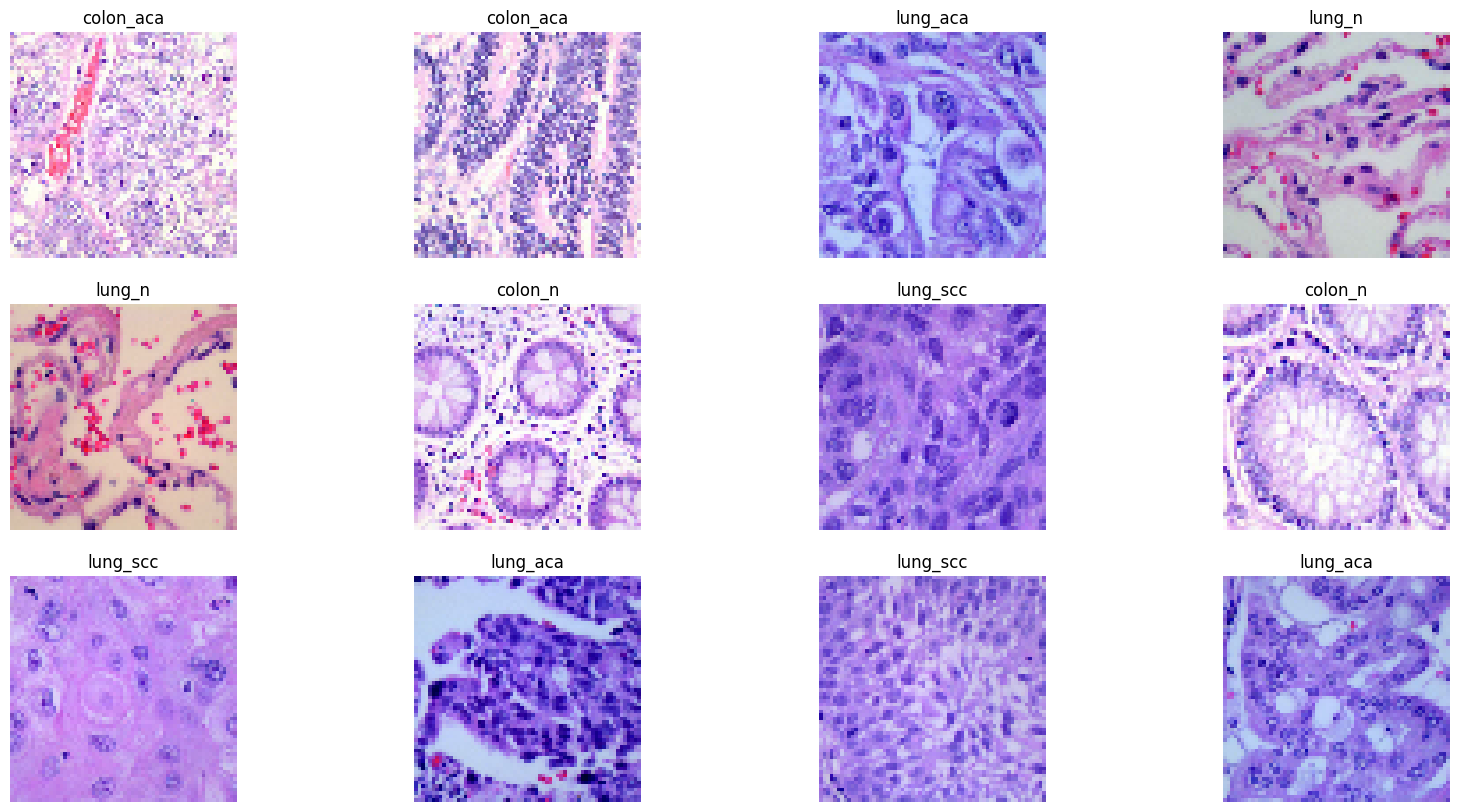

In [ ]:
mlt.figure(figsize=(20,10))
for image_batch, label_batch in data1.take(1):
    for i in range(12):
        ax = mlt.subplot(3,4,i+1)
        mlt.imshow(image_batch[i].numpy().astype('uint8'))
        mlt.title(class_names[label_batch[i]])
        mlt.axis("off")


# Spliting the data

In [ ]:
len(data1)

1563

In [ ]:
def get_dataset_div_tf(ds,train_split=0.74,val_split=0.13,test_split=0.13,shuffle=True,shuffle_size=1000):
    ds_size=len(ds)
    if shuffle:
        ds=ds.shuffle(shuffle_size,seed=5)
    train_size=int(train_split*ds_size)
    val_size=int(val_split*ds_size)

    train_ds=ds.take(train_size)
    val_ds=ds.skip(train_size).take(val_size)
    test_ds=ds.skip(train_size).skip(val_size)
    return train_ds,val_ds,test_ds


In [ ]:
train_ds,val_ds,test_ds=get_dataset_div_tf(data1)

In [ ]:
len(train_ds)

1156

In [ ]:
len(val_ds)

203

In [ ]:
len(test_ds)

204

## using gpu and cpu together

In [ ]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)


val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Data preprocessing

In [ ]:
#for slight variation like rotation,zoom etc
resize_rescale = tf.keras.Sequential([
    layers.Resizing(IMG_SIZE, IMG_SIZE),
    layers.Rescaling(1.0/255)
])
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1)
])

# Buliding the model

In [ ]:
input_shape = (IMG_SIZE, IMG_SIZE, 3)
n_classes = 5

model = models.Sequential([
    resize_rescale,
    data_augmentation,

    layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=(None, IMG_SIZE, IMG_SIZE, 3))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,597 (3.14 MB)

 Trainable params: 822,597 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25
)


Epoch 1/25
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 868s 165ms/step - accuracy: 0.6824 - loss: 0.7109 - val_accuracy: 0.7254 - val_loss: 0.6529
Epoch 2/25
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 80s 69ms/step - accuracy: 0.8118 - loss: 0.4232 - val_accuracy: 0.6730 - val_loss: 0.8133
Epoch 3/25
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 76s 66ms/step - accuracy: 0.8544 - loss: 0.3505 - val_accuracy: 0.7432 - val_loss: 0.6697
Epoch 4/25
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 77s 67ms/step - accuracy: 0.8718 - loss: 0.3129 - val_accuracy: 0.8830 - val_loss: 0.2799
Epoch 5/25
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 76s 66ms/step - accuracy: 0.8984 - loss: 0.2566 - val_accuracy: 0.8621 - val_loss: 0.3573
Epoch 6/25
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 77s 67ms/step - accuracy: 0.9123 - loss: 0.2245 - val_accuracy: 0.9249 - val_loss: 0.1916
Epoch 7/25
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 76s 66ms/step - accuracy: 0.9205 - loss: 0.2075 - val_accuracy: 0.9138 - val_loss: 0.2263
Epoch 8/25
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 82s 66ms/step - accuracy: 0.9354

In [ ]:
scores=model.evaluate(test_ds)

204/204 ━━━━━━━━━━━━━━━━━━━━ 117s 16ms/step - accuracy: 0.9342 - loss: 0.1840


# Plotting the Accuracy and Loss Curves

In [ ]:
history.params

{'verbose': 'auto', 'epochs': 25, 'steps': 1156}

In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

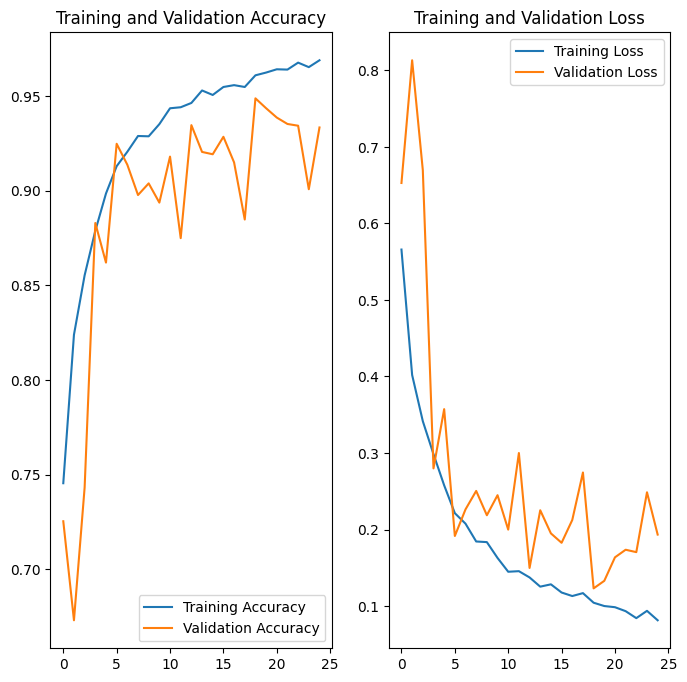

In [ ]:
mlt.figure(figsize=(8, 8))
mlt.subplot(1, 2, 1)
mlt.plot(range(25), acc, label='Training Accuracy')
mlt.plot(range(25), val_acc, label='Validation Accuracy')
mlt.legend(loc='lower right')
mlt.title('Training and Validation Accuracy')

mlt.subplot(1, 2, 2)
mlt.plot(range(25), loss, label='Training Loss')
mlt.plot(range(25), val_loss, label='Validation Loss')
mlt.legend(loc='upper right')
mlt.title('Training and Validation Loss')
mlt.show()

# function

In [ ]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


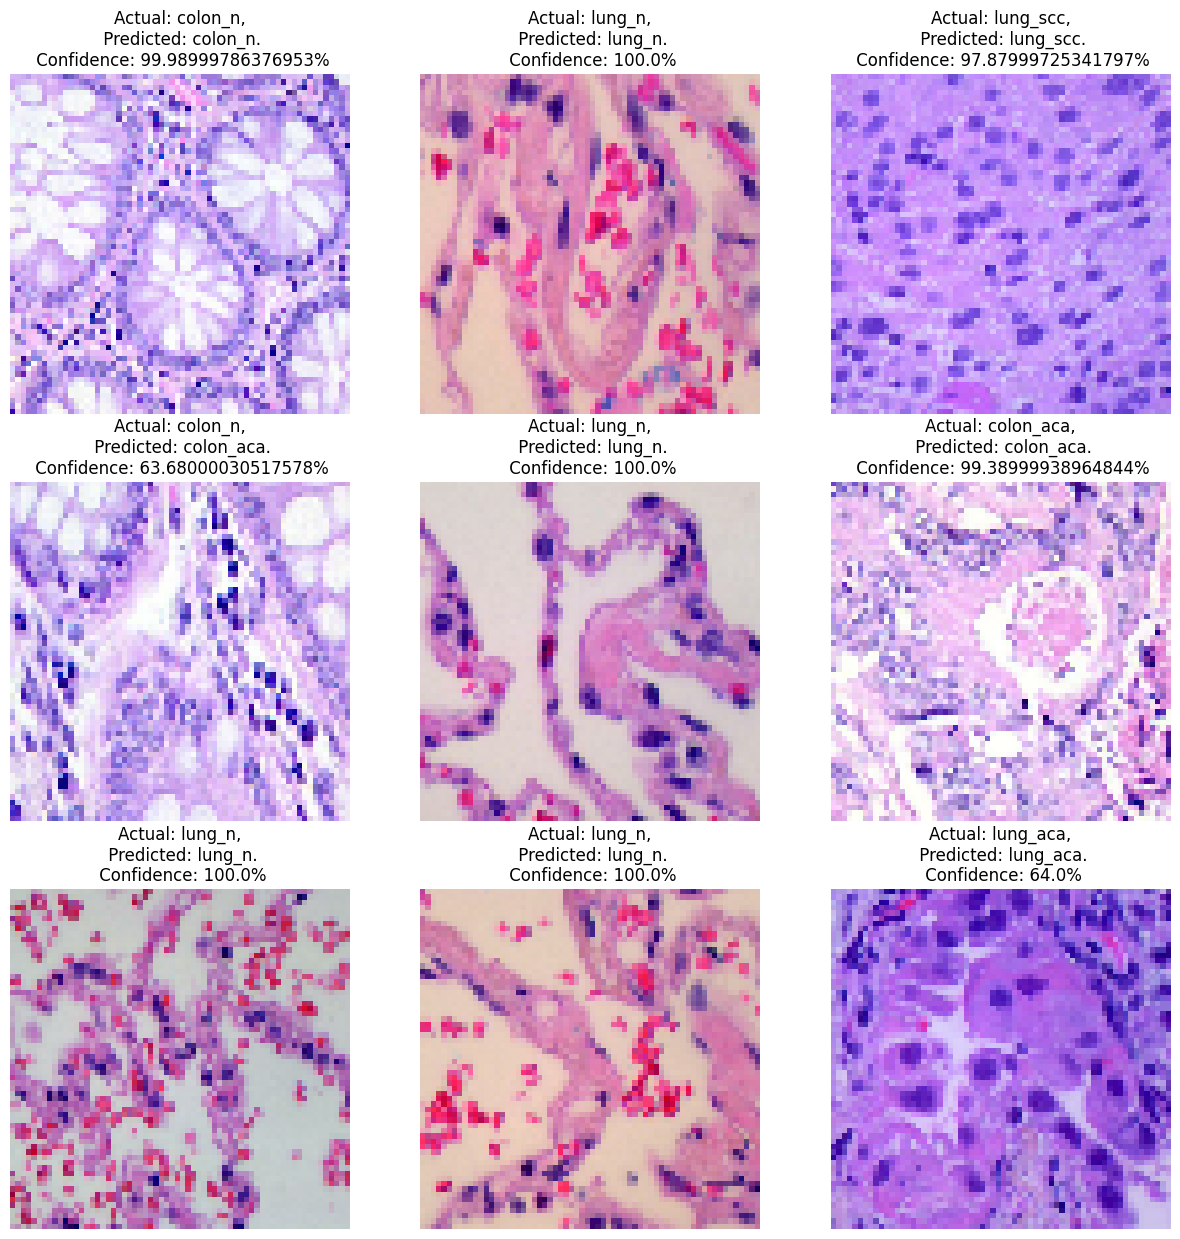

In [ ]:
mlt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = mlt.subplot(3, 3, i + 1)
        mlt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        mlt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")

        mlt.axis("off")

In [ ]:
print(class_names)

['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']


In [ ]:
data1.class_names

['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']

# Saving the model

In [ ]:
save_path = "/content/drive/MyDrive/CNN/lung_and_colon_cancer-main/training/model.keras"
model.save(save_path)
print("Model saved at:", save_path)

Model saved at: /content/drive/MyDrive/CNN/lung_and_colon_cancer-main/training/model.keras
